# Bayesian Regression, Minimally

This notebook introduces the **basic idea** of Bayesian regression in the simplest possible way.

We will focus on four ideas:

1. **Prior**: what we believe about the slope before seeing the data  
2. **Likelihood**: how well each slope explains the observed data  
3. **Posterior**: updated belief after seeing the data  
4. **Prediction with uncertainty**: Bayesian methods give a range of plausible values, not just one answer

We will use a very small example with **one input feature** and a **fixed intercept of 0** so that the main idea is easy to see.

## 1. Create a tiny synthetic dataset

We make data from a simple line with some noise:

\[
y = 3x + \text{noise}
\]

We pretend that we do **not** know the true slope. Our job is to estimate it.

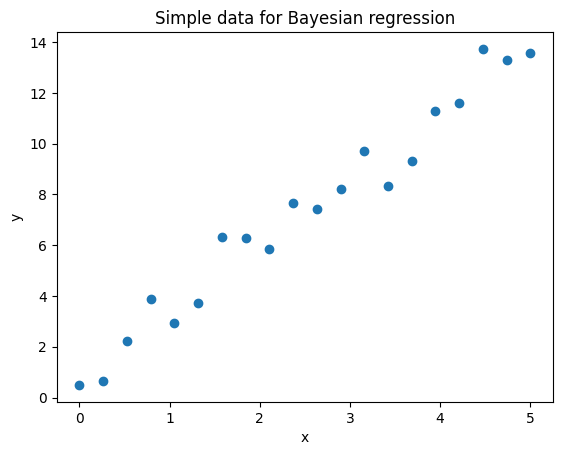

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simple one-feature dataset
x = np.linspace(0, 5, 20)
true_slope = 3.0
noise = np.random.normal(0, 1.0, size=len(x))
y = true_slope * x + noise

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simple data for Bayesian regression")
plt.show()

## 2. Define a prior over the slope

In Bayesian statistics, we start with a **prior**.

Here, the unknown quantity is the slope \(m\) in:

$
y = mx
$

We choose a simple prior:

$
m \sim \mathcal{N}(0, 5^2)
$

This means:
- before seeing the data, we think slopes near 0 are more likely
- but we still allow a wide range of possible slopes

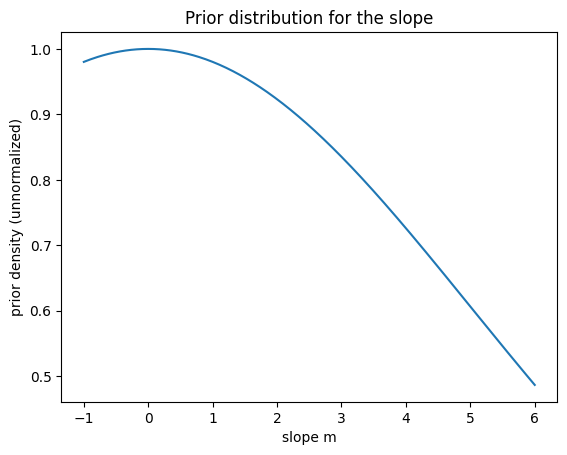

In [2]:
# Candidate slope values
m_grid = np.linspace(-1, 6, 400)

# Prior: Normal(mean=0, std=5)
prior_mean = 0
prior_std = 5
prior = np.exp(-0.5 * ((m_grid - prior_mean) / prior_std) ** 2)

plt.plot(m_grid, prior)
plt.xlabel("slope m")
plt.ylabel("prior density (unnormalized)")
plt.title("Prior distribution for the slope")
plt.show()

## 3. Compute a simple likelihood

The **likelihood** asks:

> If the slope were \(m\), how well would it explain the observed data?

We assume the noise standard deviation is known and equals 1.

For teaching purposes, we compute the likelihood on a grid of slope values.

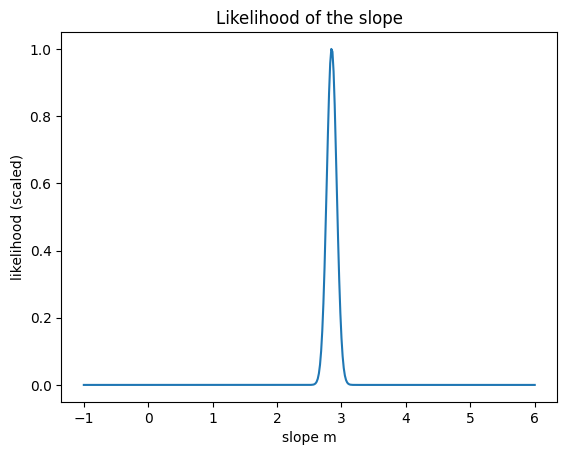

In [3]:
sigma = 1.0

# Compute likelihood on the grid
log_likelihood = []

for m in m_grid:
    y_pred = m * x
    log_like = -0.5 * np.sum(((y - y_pred) / sigma) ** 2)
    log_likelihood.append(log_like)

log_likelihood = np.array(log_likelihood)

# Stabilize numerically before exponentiating
likelihood = np.exp(log_likelihood - np.max(log_likelihood))

plt.plot(m_grid, likelihood)
plt.xlabel("slope m")
plt.ylabel("likelihood (scaled)")
plt.title("Likelihood of the slope")
plt.show()

## 4. Combine prior and likelihood to get the posterior

Bayesian updating is:

$
\text{Posterior} \propto \text{Prior} \times \text{Likelihood}
$

The posterior tells us which slope values are most plausible **after seeing the data**.

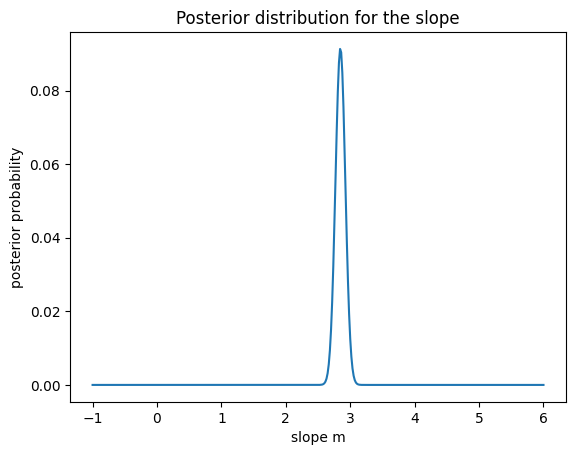

In [4]:
posterior_unnormalized = prior * likelihood
posterior = posterior_unnormalized / np.sum(posterior_unnormalized)

plt.plot(m_grid, posterior)
plt.xlabel("slope m")
plt.ylabel("posterior probability")
plt.title("Posterior distribution for the slope")
plt.show()

## 5. Find the most plausible slope and compare with the true one

A simple summary of the posterior is the slope value with the highest posterior probability.

This is called the **MAP estimate**:
- MAP = maximum a posteriori
- it is the peak of the posterior

In [5]:
m_map = m_grid[np.argmax(posterior)]

print("True slope:", true_slope)
print("MAP slope:", round(float(m_map), 3))

True slope: 3.0
MAP slope: 2.842


## 6. Plot the fitted line

We now draw the data together with the line from the MAP estimate.

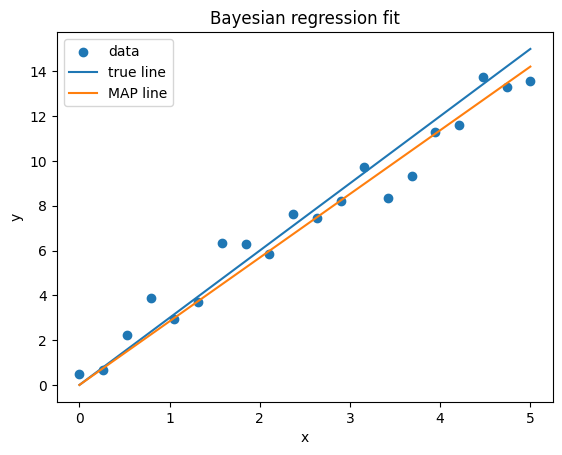

In [6]:
plt.scatter(x, y, label="data")
plt.plot(x, true_slope * x, label="true line")
plt.plot(x, m_map * x, label="MAP line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Bayesian regression fit")
plt.legend()
plt.show()

## Bayesian Regression with scikit-learn

So far, we built a simple Bayesian model manually using a grid of possible slope values.

In practice, we usually use libraries that:
- estimate the posterior automatically
- handle multiple parameters
- provide uncertainty estimates

Here we use `BayesianRidge` from scikit-learn.

Key ideas:
- The model assumes a prior over the coefficients
- It updates this using the data (likelihood)
- The result is a posterior distribution over parameters

Unlike standard linear regression, this model:
- returns a mean prediction
- also provides uncertainty (standard deviation)

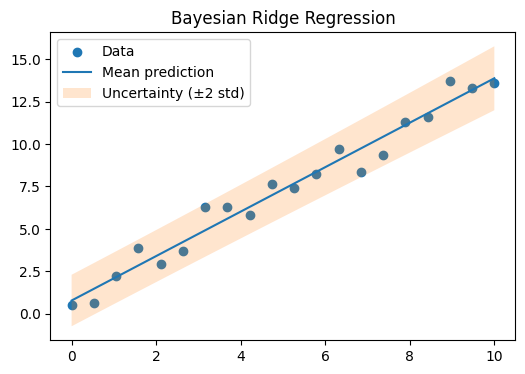

Estimated slope: 1.3084469541761872
Estimated intercept: 0.7864666676772343


In [7]:
from sklearn.linear_model import BayesianRidge
import numpy as np
import matplotlib.pyplot as plt

# Recreate the simple dataset
X_simple = np.linspace(0, 10, 20)
y_simple = y

# Reshape X for sklearn
X_sklearn = X_simple.reshape(-1, 1)

# Fit model
model = BayesianRidge()
model.fit(X_sklearn, y_simple)

# Prediction grid
X_test = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred, y_std = model.predict(X_test, return_std=True)

# Plot
plt.figure(figsize=(6, 4))
plt.scatter(X_simple, y_simple, label="Data")
plt.plot(X_test, y_pred, label="Mean prediction")
plt.fill_between(
    X_test.ravel(),
    y_pred - 2 * y_std,
    y_pred + 2 * y_std,
    alpha=0.2,
    label="Uncertainty (±2 std)"
)
plt.title("Bayesian Ridge Regression")
plt.legend()
plt.show()

print("Estimated slope:", model.coef_[0])
print("Estimated intercept:", model.intercept_)

## 8. Main takeaway

The basic Bayesian workflow is:

1. choose a **prior**
2. compute the **likelihood**
3. multiply them to get the **posterior**
4. use the posterior for **estimation and uncertainty**

In this notebook we used a very simple one-parameter example so the main ideas stay visible.

In more realistic Bayesian regression:
- the intercept is also unknown
- there can be many features
- we usually use more advanced tools rather than a grid over one parameter